# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

# 🧠 Stroke Risk Prediction Dataset (Version 2)

## 📌 Sumber Dataset
Dataset ini diperoleh dari Kaggle:

🔗 https://www.kaggle.com/datasets/mahatiratusher/stroke-risk-prediction-dataset-v2/data

---

## 📊 Deskripsi Dataset
**Stroke Risk Prediction Dataset (Version 2)** adalah dataset sintetis berbasis literatur medis yang digunakan untuk memprediksi risiko stroke berdasarkan faktor demografi dan gejala klinis.

Dataset ini telah mengalami peningkatan dibanding versi sebelumnya dengan mempertimbangkan:
- Distribusi risiko berbasis usia (non-linear/sigmoid)
- Faktor risiko berbasis gender
- Validasi berdasarkan literatur medis (WHO, Harrison’s, dll.)

---

## 🔢 Informasi Umum Dataset
- Jumlah data: **35,000 sampel**
- Jumlah fitur: **16 fitur**
- Target:
  - **at_risk** → klasifikasi (0 = tidak berisiko, 1 = berisiko)
  - **stroke_risk_percentage** → regresi (0–100%)

- Distribusi kelas:
  - 50% berisiko
  - 50% tidak berisiko

---

## 🧾 Struktur Fitur

| Fitur | Tipe | Deskripsi |
|------|------|----------|
| age | Integer | Usia (18–90 tahun) |
| gender | String | Jenis kelamin (Male/Female) |
| chest_pain | Binary | Nyeri dada |
| shortness_of_breath | Binary | Sesak napas |
| irregular_heartbeat | Binary | Detak jantung tidak teratur |
| fatigue_weakness | Binary | Kelelahan |
| dizziness | Binary | Pusing |
| swelling_edema | Binary | Pembengkakan |
| neck_jaw_pain | Binary | Nyeri leher/rahang |
| excessive_sweating | Binary | Keringat berlebih |
| persistent_cough | Binary | Batuk berkepanjangan |
| nausea_vomiting | Binary | Mual/muntah |
| high_blood_pressure | Binary | Tekanan darah tinggi |
| chest_discomfort | Binary | Ketidaknyamanan dada |
| cold_hands_feet | Binary | Tangan/kaki dingin |
| snoring_sleep_apnea | Binary | Sleep apnea |
| anxiety_doom | Binary | Kecemasan |
| at_risk | Binary | Target klasifikasi |
| stroke_risk_percentage | Float | Target regresi |

---

## 🧬 Karakteristik Penting Dataset

### 1. Age-Based Risk Modeling
Risiko stroke meningkat secara **non-linear (sigmoid)**, terutama setelah usia 50 tahun.

### 2. Gender-Based Risk
- Pria < 60 tahun → risiko 1.5× lebih tinggi
- Wanita > 60 tahun → risiko 1.8× lebih tinggi

### 3. Feature Engineering Medis
Bobot fitur didasarkan pada literatur medis, contoh:
- Tekanan darah tinggi → faktor risiko utama
- Detak jantung tidak teratur → meningkatkan risiko stroke signifikan

### 4. Data Seimbang
Dataset memiliki distribusi kelas yang seimbang untuk:
- Mengurangi bias model
- Meningkatkan performa klasifikasi (AUC, F1-score)

---

## 🎯 Tujuan Penggunaan Dataset

Dataset ini dapat digunakan untuk:
- 🔹 Klasifikasi: Prediksi apakah seseorang berisiko stroke
- 🔹 Regresi: Estimasi persentase risiko stroke
- 🔹 Explainable AI (XAI): Interpretasi faktor risiko
- 🔹 Penelitian machine learning pada data medis sintetis

---

## ⚠️ Catatan
- Dataset ini bersifat **sintetis**, namun berbasis literatur medis
- Cocok untuk penelitian dan eksperimen machine learning
- Tidak digunakan untuk diagnosis klinis langsung


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load the dataset
data_path = '../stroke_risk_dataset_raw/stroke_risk_dataset_v2_raw.csv'
df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
print("Columns in dataset:", df.columns.tolist())
display(df.head())

Dataset shape: (35000, 19)
Columns in dataset: ['age', 'gender', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'swelling_edema', 'neck_jaw_pain', 'excessive_sweating', 'persistent_cough', 'nausea_vomiting', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'anxiety_doom', 'stroke_risk_percentage', 'at_risk']


,age,gender,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,stroke_risk_percentage,at_risk
0,22,Male,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,33.3,0
1,52,Male,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,100.0,1
2,63,Female,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,100.0,1
3,41,Male,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,44.5,0
4,53,Male,0,0,0,0,0,1,1,0,0,0,1,0,1,0,0,84.8,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

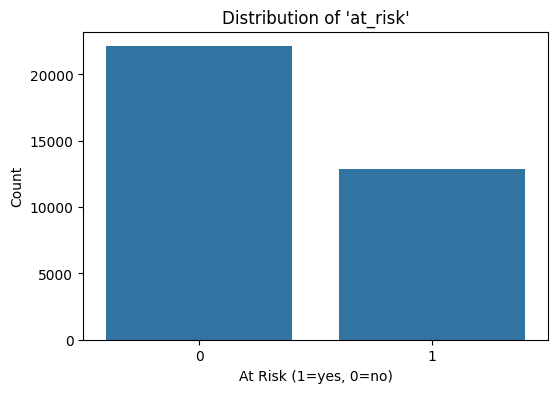


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     35000 non-null  int64  
 1   gender                  35000 non-null  object 
 2   chest_pain              35000 non-null  int64  
 3   high_blood_pressure     35000 non-null  int64  
 4   irregular_heartbeat     35000 non-null  int64  
 5   shortness_of_breath     35000 non-null  int64  
 6   fatigue_weakness        35000 non-null  int64  
 7   dizziness               35000 non-null  int64  
 8   swelling_edema          35000 non-null  int64  
 9   neck_jaw_pain           35000 non-null  int64  
 10  excessive_sweating      35000 non-null  int64  
 11  persistent_cough        35000 non-null  int64  
 12  nausea_vomiting         35000 non-null  int64  
 13  chest_discomfort        35000 non-null  int64  
 14  cold_hands_feet         35

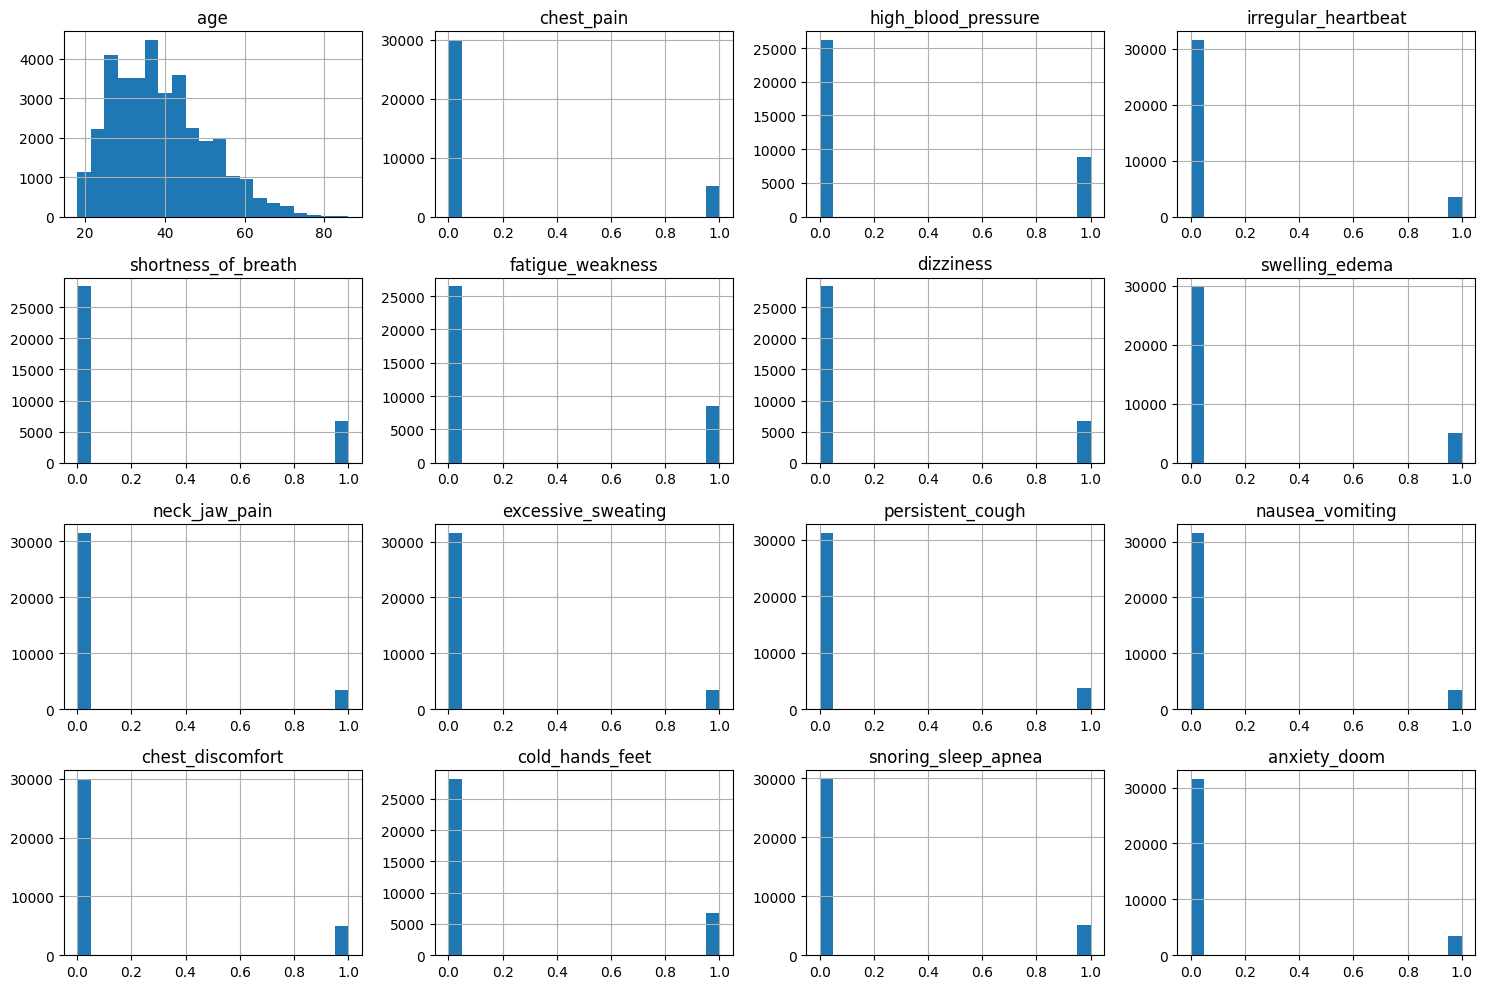

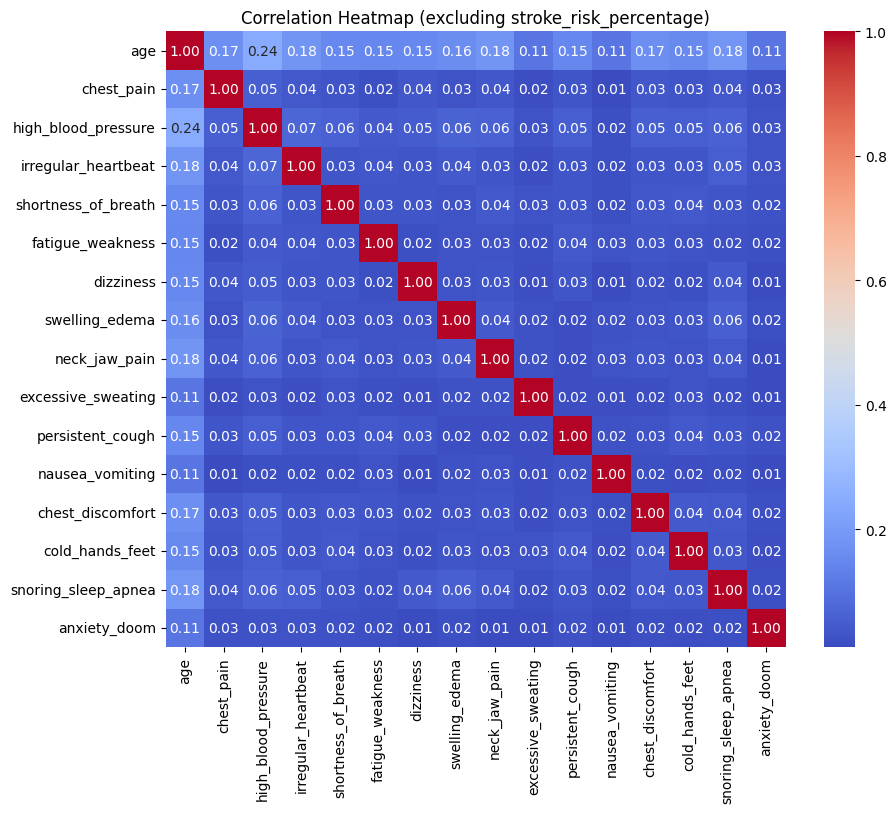

In [3]:
# Define target variable
target = 'at_risk'
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found. Available columns: {df.columns.tolist()}")

# Plot target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title("Distribution of 'at_risk'")
plt.xlabel("At Risk (1=yes, 0=no)")
plt.ylabel("Count")
plt.show()

# Data information and missing values
print("\nData Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics for numerical features
print("\nSummary Statistics:")
print(df.describe())

# List numeric features (excluding target and stroke_risk_percentage)
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in [target, 'stroke_risk_percentage']:
    if col in numeric_features:
        numeric_features.remove(col)

# Histograms for numeric features
df[numeric_features].hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features (excluding stroke_risk_percentage)
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (excluding stroke_risk_percentage)")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
df.isnull().sum()

age                       0
gender                    0
chest_pain                0
high_blood_pressure       0
irregular_heartbeat       0
shortness_of_breath       0
fatigue_weakness          0
dizziness                 0
swelling_edema            0
neck_jaw_pain             0
excessive_sweating        0
persistent_cough          0
nausea_vomiting           0
chest_discomfort          0
cold_hands_feet           0
snoring_sleep_apnea       0
anxiety_doom              0
stroke_risk_percentage    0
at_risk                   0
dtype: int64

In [5]:
# ================================
# 📌 Identifikasi Fitur Kategorikal
# ================================
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical Features:", categorical_features)

# ================================
# 📌 Handle Missing Values
# ================================
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# ================================
# 📌 Pisahkan Feature & Target
# ================================
features_to_drop = [target, 'stroke_risk_percentage']
X = df.drop(columns=features_to_drop)
y = df[target]

# ================================
# 📌 Identifikasi Fitur Numerik
# ================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ================================
# 📌 Preprocessing Pipeline
# ================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# ================================
# 📌 Transform Data
# ================================
X_processed = preprocessor.fit_transform(X)

# ================================
# 📌 Ambil Nama Fitur Baru
# ================================
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)



Categorical Features: ['gender']


In [6]:
# ================================
# 📌 Convert ke DataFrame
# ================================
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

# Gabungkan dengan target
final_df = pd.concat([X_processed_df, y.reset_index(drop=True)], axis=1)

print("\nHasil preprocessing:")
final_df.head()


Hasil preprocessing:


,age,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,gender_Male,at_risk
0,-1.438103,2.419922,-0.580298,-0.330469,-0.484412,-0.568948,-0.485401,-0.413379,-0.332433,-0.328711,2.904566,-0.328764,-0.409771,-0.491503,-0.415272,-0.330628,1.0,0
1,1.156163,-0.413236,1.723254,3.026005,-0.484412,-0.568948,-0.485401,-0.413379,-0.332433,-0.328711,-0.344285,-0.328764,-0.409771,2.034576,2.408061,-0.330628,1.0,1
2,2.107394,-0.413236,1.723254,-0.330469,-0.484412,-0.568948,2.060153,-0.413379,-0.332433,-0.328711,-0.344285,-0.328764,-0.409771,-0.491503,-0.415272,-0.330628,0.0,1
3,0.204932,-0.413236,-0.580298,3.026005,-0.484412,1.757630,-0.485401,-0.413379,-0.332433,-0.328711,-0.344285,-0.328764,-0.409771,-0.491503,-0.415272,-0.330628,1.0,0
4,1.242639,-0.413236,-0.580298,-0.330469,-0.484412,-0.568948,2.060153,2.419090,-0.332433,-0.328711,-0.344285,3.041694,-0.409771,2.034576,-0.415272,-0.330628,1.0,1


In [7]:
# ================================
# 📌 Simpan ke CSV
# ================================
output_dir = "./stroke_risk_dataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)

output_filepath = os.path.join(output_dir, "stroke_risk_dataset_v2_preprocessing.csv")

final_df.to_csv(output_filepath, index=False)

print(f"\n✅ Dataset preprocessing berhasil disimpan di: {output_filepath}")


✅ Dataset preprocessing berhasil disimpan di: ./stroke_risk_dataset_preprocessing\stroke_risk_dataset_v2_preprocessing.csv
